In [1]:
import pandas as pd
import numpy as np
from itertools import product, combinations
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from pylatexenc.latexencode import unicode_to_latex as text2latex
from scipy import stats


sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.helpers import make_aesthetic, cat_stats
from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula
import random

random.seed(42)
np.random.seed(42)

mypal = make_aesthetic()

def did_use(x):
    if "never" in x.lower():
        return 0
    else:
        return 1

def short_domain(x):
    if "convention" in x.lower():
        return "conventional"
    elif "moral" in x.lower():
        return "moral"
    elif "personal" in x.lower():
        return "personal"
    else:
        return "other"

df = pd.read_csv("../data/qualtrics_experiments/desc_norms_interface [typing]_August 23, 2025_17.08.csv")
# print(sorted(df.columns))
df = df.iloc[2:]
df = df.query("DistributionChannel=='anonymous'")

data_pts = []
for _, row in df.iterrows():
    # non_loop_merge_vars
    base_pt = {
        "pid": row['ResponseId'],
        "progress": row['Progress'],
        "duration": float(row['Duration (in seconds)'])/60,
        "finished": row['Finished'],
        "llm_usage": row['dv_llm_usage'],
        "usage_convention": row['dv_usage_convention'],
        "usage_moral": row['dv_usage_moral'],
        "usage_personal": row['dv_usage_personal'],
        "llm_usage_binary": did_use(row['dv_llm_usage']),
        "usage_convention_binary": did_use(row['dv_usage_convention']),
        "usage_moral_binary": did_use(row['dv_usage_moral']),
        "usage_personal_binary": did_use(row['dv_usage_personal']),
    }

    # loop and merge columns:
    for i in range(1, 60):
        pre = float(row.get(f'{i}_lm_pre_11'))
        post =float( row.get(f'{i}_lm_post_11'))
        qual = row.get(f'{i}_lm_qual')
        if pd.notnull(pre) and pd.notnull(post):
            data_pt = base_pt.copy()
            data_pt['idx'] = i
            data_pt['pre'] = pre
            data_pt['post'] = post
            data_pt['qual'] = qual
            data_pts.append(data_pt)

df = pd.DataFrame(data_pts)
meta_df = pd.read_csv("../data/clean/ai_rot_stimuli_new_prompt.csv")
df = df.merge(meta_df, on='idx', how='left')
df['sum_usage'] = df[['usage_convention_binary', 'usage_moral_binary', 'usage_personal_binary']].sum(axis=1)

df['pre_distance'] = np.abs(df['pre'] - df['rating'])
df['post_distance'] = np.abs(df['post'] - df['rating'])
df['change_distance'] = df['pre_distance'] - df['post_distance']
df['domain'] = df['domain'].map(short_domain)

 # Descriptives of change

/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_29465/1804359511.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


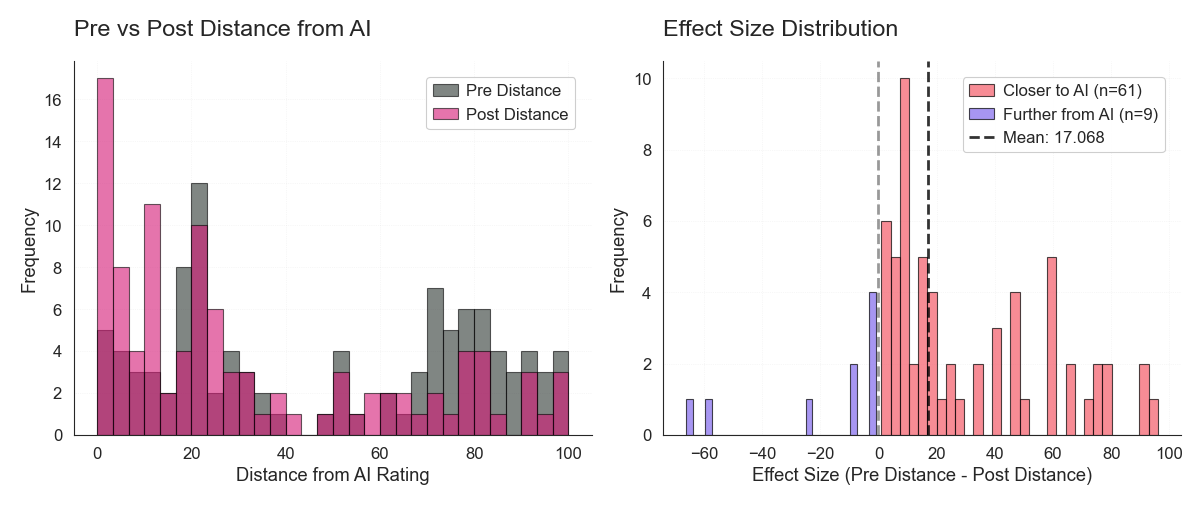


    The mean effect (pre-distance minus post-distance) was 17.07 (SD = 28.88), with a Cohen's dz of 0.59 (95% CI [0.41, 0.76]). In 59% of cases, participants moved closer to the AI rating, while in 9% of cases they moved further away, and in 32% of cases there was no change. A Wilcoxon signed-rank test indicates that this change is statistically significant (W = 206.0, p = 1.3e-09).


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from src.helpers import array_stats

mypal = make_aesthetic(font_scale=1.2)
effect_size = df['pre_distance'] - df['post_distance']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pre_distance and post_distance as overlaid histograms
#################################################################
#################################################################
ax1 = axes[0]
ax1.hist(df['pre_distance'], bins=30, alpha=0.6, label='Pre Distance',  edgecolor='black')
ax1.hist(df['post_distance'], bins=30, alpha=0.6, label='Post Distance', edgecolor='black')
ax1.set_xlabel('Distance from AI Rating')
ax1.set_ylabel('Frequency')
ax1.set_title('Pre vs Post Distance from AI')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Distribution of effect sizes
#################################################################
#################################################################
ax2 = axes[1]
closer_to_ai = effect_size[effect_size > 0]
further_from_ai = effect_size[effect_size < 0]

ax2.hist(closer_to_ai, bins=30, alpha=0.7, label=f'Closer to AI (n={len(closer_to_ai)})',
color=mypal[4], edgecolor='black')
ax2.hist(further_from_ai, bins=30, alpha=0.7, label=f'Further from AI (n={len(further_from_ai)})',
         color=mypal[3], edgecolor='black')
ax2.axvline(0, color='gray', linestyle='--', alpha=0.8, linewidth=2)
ax2.axvline(effect_size.mean(), color='black', linestyle='--', alpha=0.8, linewidth=2,
            label=f'Mean: {effect_size.mean():.3f}')

ax2.set_xlabel('Effect Size (Pre Distance - Post Distance)')
ax2.set_ylabel('Frequency')
ax2.set_title('Effect Size Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Statistics
######################################
######################################
def bootstrap_dz(data, n_bootstraps=10000):
    boot_dz = []
    n = len(data)
    for _ in range(n_bootstraps):
        sample = np.random.choice(data, size=n, replace=True)
        mean_diff = np.mean(sample)
        sd_diff = np.std(sample, ddof=1)
        if sd_diff != 0:
            boot_dz.append(mean_diff / sd_diff)
    return np.percentile(boot_dz, [2.5, 97.5])


def compute_change_metrics(pre, post):
    effect_size = pre - post
    mean_diff = effect_size.mean()
    sd_diff = effect_size.std()
    cohens_dz = mean_diff / sd_diff
    ci_lower, ci_upper = bootstrap_dz(effect_size)
    moved_closer = effect_size > 0
    moved_further = effect_size < 0
    no_change = effect_size == 0
    wilcox_w = stats.wilcoxon(pre, post)

    # Calculate percentages
    n = len(effect_size)
    percent_closer = moved_closer.sum() / n
    percent_further = moved_further.sum() / n
    percent_no_change = no_change.sum() / n

    data =  {
        "mean_diff": mean_diff,
        "sd_diff": sd_diff,
        "cohens_dz": cohens_dz,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "moved_closer": moved_closer,
        "moved_further": moved_further,
        "no_change": no_change,
        "wilcox_w": wilcox_w.statistic,
        "wilcox_p": wilcox_w.pvalue
    }
    stats_str = f"""
    The mean effect (pre-distance minus post-distance) was {mean_diff:.2f} (SD = {sd_diff:.2f}), with a Cohen's dz of {cohens_dz:.2f} (95% CI [{ci_lower:.2f}, {ci_upper:.2f}]). In {percent_closer*100:.0f}% of cases, participants moved closer to the AI rating, while in {percent_further*100:.0f}% of cases they moved further away, and in {percent_no_change*100:.0f}% of cases there was no change. A Wilcoxon signed-rank test indicates that this change is statistically significant (W = {wilcox_w.statistic}, p = {wilcox_w.pvalue:.1e})."""
    print(stats_str)
    return data

metrics = compute_change_metrics(df['pre_distance'], df['post_distance'])



## By factors

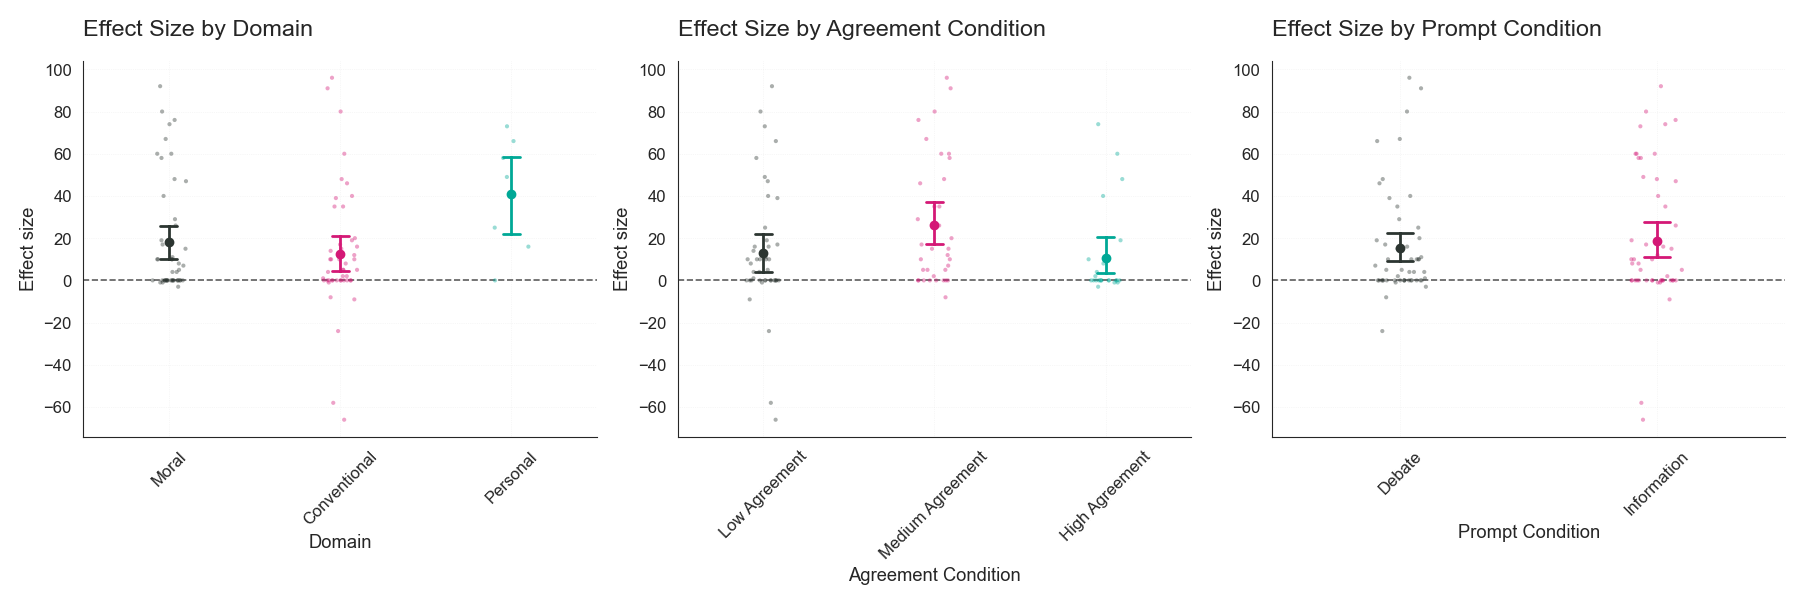

                            OLS Regression Results                            
Dep. Variable:        change_distance   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     5.183
Date:                Sat, 23 Aug 2025   Prob (F-statistic):             0.0204
Time:                        19:48:08   Log-Likelihood:                -483.47
No. Observations:                 103   AIC:                             978.9
Df Residuals:                      97   BIC:                             994.8
Df Model:                           5                                         
Covariance Type:              cluster                                         
                                                                                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

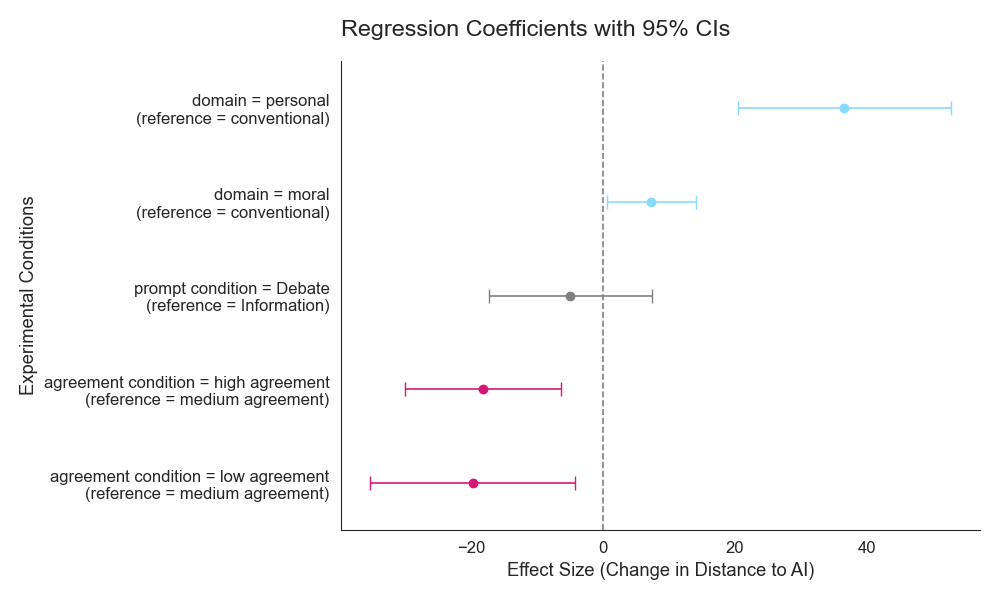

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


# Grid plot by factors
#############################################
#############################################
mypal = make_aesthetic(font_scale=1.2)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
mypal = make_aesthetic(font_scale=1.2)
factors = ['domain', 'agreement_condition', 'prompt_condition']
factor_titles = ['Domain', 'Agreement Condition', 'Prompt Condition']

for i, (factor, title) in enumerate(zip(factors, factor_titles)):
    ax = axes[i]

    sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
                 capsize=0.1, errwidth=2, ax=ax)

    sns.stripplot(x=factor, y='change_distance', data=df, palette=mypal,
                 alpha=0.4, size=3, ax=ax)

    ax.axhline(y=0, color='k', linestyle='--', alpha=0.7)

    labels = [label.get_text().replace('_', ' ').title() for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=45)

    ax.set_title(f"Effect Size by {title}")
    ax.set_ylabel("Effect size")
    ax.set_xlabel(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#############################################
#############################################


# Clustered regression analysis
#############################################
#############################################

formula = 'change_distance ~ C(domain, Treatment(reference="conventional")) + C(agreement_condition, Treatment(reference="medium_agreement")) + C(prompt_condition, Treatment(reference="Information"))'

model = smf.ols(formula, data=df).fit(
    cov_type='cluster',
    cov_kwds={'groups': df['pid']}
)
print(model.summary())

from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula

handler = StatsmodelsHandler(model)
handler.to_latex()
handler.plot(clean_var_name=clean_var_name_from_formula)
plt.xlabel("Effect Size (Change in Distance to AI)")
plt.ylabel("Experimental Conditions")
plt.title("Regression Coefficients with 95% CIs")
plt.show()
#############################################
#############################################

# Transition Dynamics

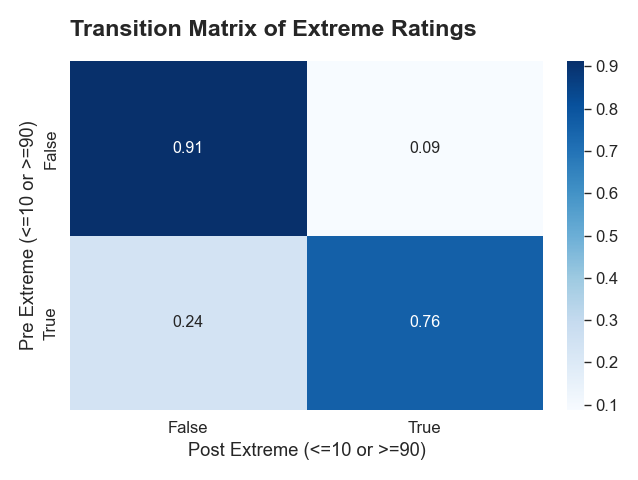

Text(0.0, 1.0, 'Transition Matrix of Rating Buckets')

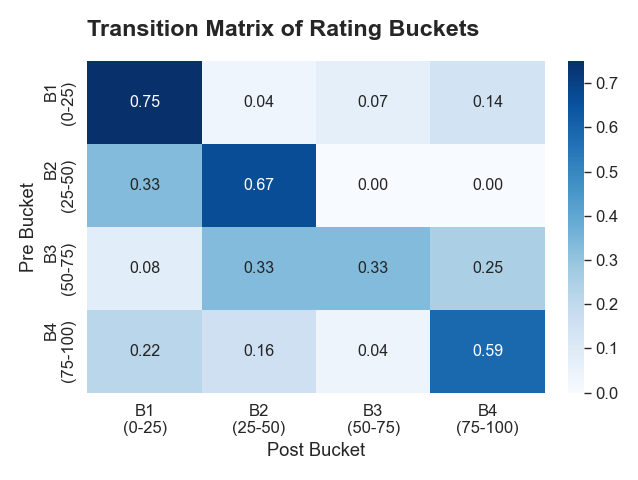

In [5]:
def is_extreme(x):
    return x < 10 or x > 90

def bucket_label(x, n_bins):
    bins = np.linspace(0, 100, n_bins + 1)
    labels = [f"B{i+1}\n({int(bins[i])}-{int(bins[i+1])})" for i in range(n_bins)]
    return pd.cut([x], bins=bins, labels=labels, include_lowest=True)[0]


from src.helpers import make_aesthetic
mypal = make_aesthetic(font_scale=1.2)


df['pre_extreme'] = df['pre'].apply(is_extreme)
df['post_extreme'] = df['post'].apply(is_extreme)


# Transition matrix of extremes
####################################
####################################
sns.heatmap(
    pd.crosstab(df['pre_extreme'], df['post_extreme'], normalize='index'),
    annot=True, fmt=".2f", cmap="Blues"
)
plt.xlabel("Post Extreme (<=10 or >=90)")
plt.ylabel("Pre Extreme (<=10 or >=90)")
plt.title("Transition Matrix of Extreme Ratings", fontweight='bold')
plt.show()
####################################
####################################

# Transition matrix of pre/post buckets
####################################
####################################
N_BINS=4
df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['post_bucket'] = df['post'].apply(bucket_label, n_bins=N_BINS)
sns.heatmap(
    pd.crosstab(df['pre_bucket'], df['post_bucket'], normalize='index'),
    annot=True, fmt=".2f", cmap="Blues"
)
plt.xlabel("Post Bucket")
plt.ylabel("Pre Bucket")
plt.title("Transition Matrix of Rating Buckets", fontweight='bold')
####################################
####################################



####################################

## Where changes come from

Text(0, 0.5, 'Change Distance')

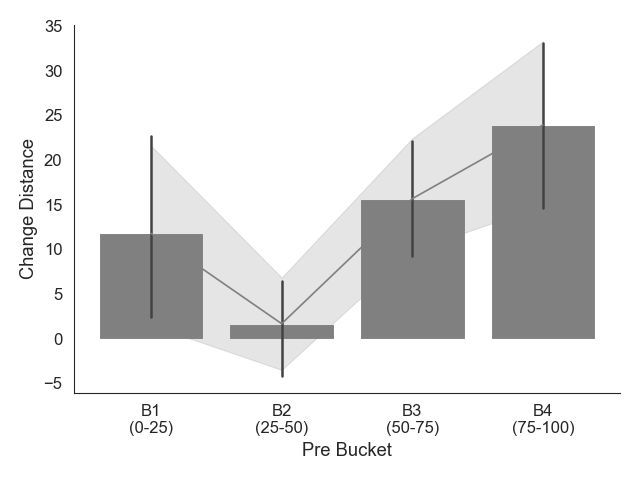

In [19]:
N_BINS=4
df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['post_bucket'] = df['post'].apply(bucket_label, n_bins=N_BINS)
df = df.sort_values(by=['pre_bucket'])

sns.barplot(data=df, x='pre_bucket', y='change_distance', color='gray')
sns.lineplot(data=df, x='pre_bucket', y='change_distance', color='gray')
plt.xlabel("Pre Bucket")
plt.ylabel("Change Distance")


# Individual differences

<Axes: xlabel='change_distance', ylabel='pid'>

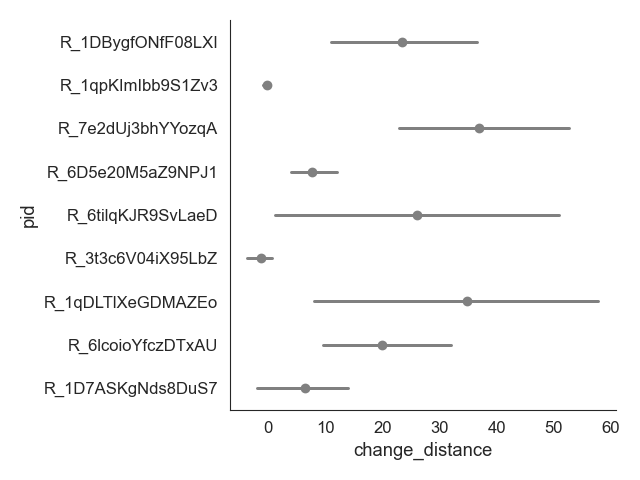

In [29]:
pid_cols = [c for c in df.columns if "usage" in c] + ["pid"]

byp = (
    df.groupby(pid_cols)['change_distance']
      .agg(mean=np.mean, sd=np.std)
      .reset_index()
)
sns.pointplot(data=df, y='pid', x='change_distance', color='gray', join=False)


In [51]:
%R install.packages("ggplot2")

UsageError: Line magic function `%R` not found.
